In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense

In [33]:
df = pd.read_csv('Tweets.csv')

In [34]:
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [35]:
df = df[['selected_text', 'sentiment']]
# df.columns = ['text', 'sentiment']
# df['text'] = df['text'].str.lower()
df.head()

,selected_text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD,negative
2,bullying me,negative
3,leave me alone,negative
4,"Sons of ****,",negative


In [36]:
df.dropna(inplace=True)

In [37]:
X = df['selected_text']
y = df['sentiment']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
Tokenizer = Tokenizer(num_words=8000)
Tokenizer.fit_on_texts(X_train)
X_train_seq = Tokenizer.texts_to_sequences(X_train)
X_test_seq = Tokenizer.texts_to_sequences(X_test)

In [40]:
X_train_pad = pad_sequences(X_train_seq, maxlen=50)
X_test_pad = pad_sequences(X_test_seq, maxlen=50)

In [41]:
def rnn_creation():
    model = Sequential()
    model.add(Embedding(8000, 128, input_length=50))
    model.add(SimpleRNN(32))
    model.add(Dense(3, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [42]:
def LSTM_creation():
    model = Sequential()
    model.add(Embedding(8000, 128, input_length=50))
    model.add(LSTM(32))
    model.add(Dense(3, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [43]:
rnn_model = rnn_creation()
lstm_model = LSTM_creation()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [44]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

rnn_history = rnn_model.fit(X_train_pad, y_train_encoded, epochs=10, batch_size=64, validation_split=0.2)

lstm_history = lstm_model.fit(X_train_pad, y_train_encoded, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7308 - loss: 0.6661 - val_accuracy: 0.8126 - val_loss: 0.5117
Epoch 2/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8721 - loss: 0.3654 - val_accuracy: 0.8144 - val_loss: 0.4977
Epoch 3/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9165 - loss: 0.2462 - val_accuracy: 0.8110 - val_loss: 0.5535
Epoch 4/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9438 - loss: 0.1749 - val_accuracy: 0.7965 - val_loss: 0.6068
Epoch 5/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9585 - loss: 0.1350 - val_accuracy: 0.7935 - val_loss: 0.6770
Epoch 6/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9657 - loss: 0.1123 - val_accuracy: 0.8049 - val_loss: 0.7265
Epoch 7/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9703 - loss: 0.0959 - val_accuracy: 0.7965 - val_loss: 0.7808
Epoch 8/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9740 - loss: 0.0854 - val_accuracy: 0

In [45]:
rnn_prob = rnn_model.predict(X_test_pad)
rnn_pred = np.argmax(rnn_prob, axis=1)
rnn_acc = accuracy_score(y_test_encoded, rnn_pred)

lstm_prod = lstm_model.predict(X_test_pad)
lstm_pred = np.argmax(lstm_prod, axis=1)
lstm_acc = accuracy_score(y_test_encoded, lstm_pred)


print(f"RNN Accuracy: {rnn_acc}")
print(f"LSTM Accuracy: {lstm_acc}")

172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RNN Accuracy: 0.7925764192139738
LSTM Accuracy: 0.8044032023289666


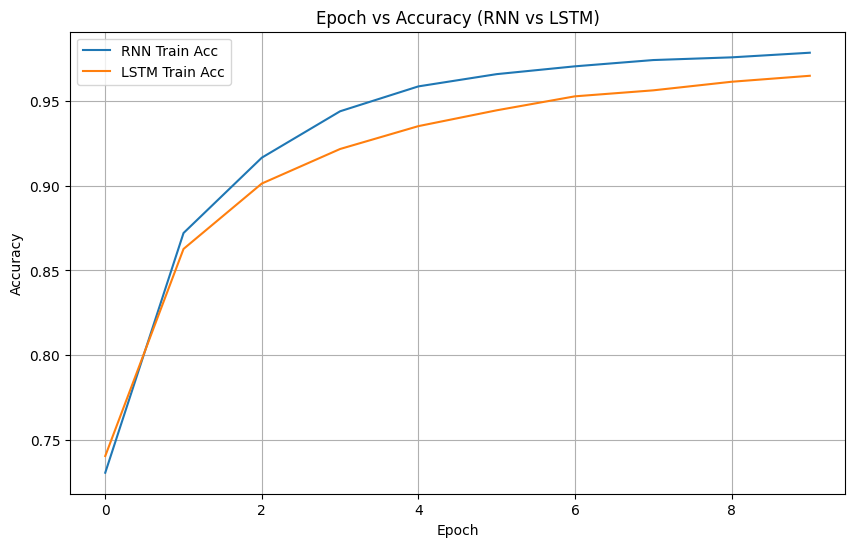

In [47]:
plt.figure(figsize=(10,6))

plt.plot(rnn_history.history['accuracy'], label="RNN Train Acc")
# plt.plot(rnn_history.history['val_accuracy'], label="RNN Val Acc")

plt.plot(lstm_history.history['accuracy'], label="LSTM Train Acc")
# plt.plot(lstm_history.history['val_accuracy'], label="LSTM Val Acc")

plt.title("Epoch vs Accuracy (RNN vs LSTM)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()